In [10]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐 방지

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Admin\Desktop\hhh\Horse\data_preprocessing\merged_data_kr_Nan.csv", encoding="utf-8-sig")

In [5]:
df.head()

,분할경주여부,마명,마번,기수번호,조교사번호,부담구분,출전번호,경주일자,경주거리,경주등급,...,경주로상태,날씨,마체중,출생일,성별,소유자명,생산국,부마명,소재지,순위점수
0,0,파이널축제,45339,080342,70170.0,2,3,2023-01-07,1300,일반,...,양호,흐림,490.0,2020-03-10,수,럭키,한국,지롤라모,서울경마공원,0.636364
1,0,아르고리치,45921,080366,70146.0,2,6,2023-01-07,1300,일반,...,양호,흐림,496.0,2020-04-08,수,우태율,한국,컬러즈플라잉,서울경마공원,0.909091
2,0,파워에치드,45734,080339,70166.0,2,11,2023-01-07,1300,일반,...,양호,흐림,483.0,2020-03-18,거,박정재,한국,에치드,서울경마공원,0.363636
3,0,베스트선,45369,080405,70115.0,3,1,2023-01-07,1300,일반,...,양호,흐림,479.0,2020-02-28,거,베스트샤인조합,한국,테이크차지인디,서울경마공원,0.818182
4,0,슈어윈,45240,080103,70096.0,3,7,2023-01-07,1300,일반,...,양호,흐림,413.0,2020-02-13,암,지성배,한국,BERNARDINI,서울경마공원,1.000000


In [6]:
df.columns

Index(['분할경주여부', '마명', '마번', '기수번호', '조교사번호', '부담구분', '출전번호', '경주일자', '경주거리',
       '경주등급', '출전마구분', '경주번호', '야간경마여부', '순위', '마필등급', '경주기록', '출주두수',
       '경주로상태', '날씨', '마체중', '출생일', '성별', '소유자명', '생산국', '부마명', '소재지', '순위점수'],
      dtype='str')

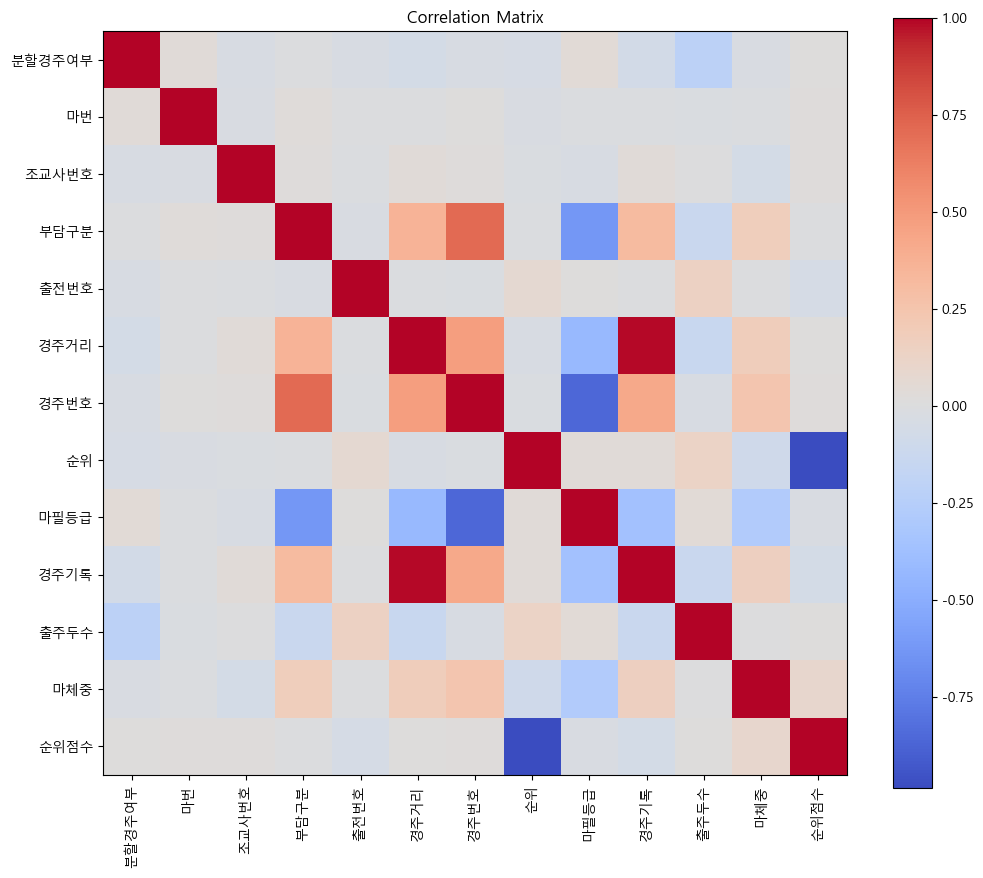

In [11]:
import matplotlib.pyplot as plt
import numpy as np

num_df = df.select_dtypes(include=[np.number])

corr = num_df.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.show()

In [14]:
import numpy as np

num_df = df.select_dtypes(include=[np.number])

num_df.corr()

,분할경주여부,마번,조교사번호,부담구분,출전번호,경주거리,경주번호,순위,마필등급,경주기록,출주두수,마체중,순위점수
분할경주여부,1.000000,0.034429,-0.034133,-0.004997,-0.036800,-0.058077,-0.032341,-0.041483,0.044867,-0.065358,-0.210820,-0.028056,0.012182
마번,0.034429,1.000000,-0.028219,0.023001,-0.001139,-0.005219,0.013267,-0.024140,-0.009212,-0.008250,-0.023025,-0.008979,0.020360
조교사번호,-0.034133,-0.028219,1.000000,0.020882,-0.012305,0.035280,0.021880,-0.016557,-0.034920,0.032166,0.003977,-0.062300,0.018472
부담구분,-0.004997,0.023001,0.020882,1.000000,-0.025613,0.358976,0.706296,-0.009551,-0.626830,0.313219,-0.132198,0.172035,-0.004471
출전번호,-0.036800,-0.001139,-0.012305,-0.025613,1.000000,-0.012206,-0.016885,0.068785,0.014008,-0.006192,0.140322,-0.001342,-0.048747
경주거리,-0.058077,-0.005219,0.035280,0.358976,-0.012206,1.000000,0.477451,-0.035063,-0.424361,0.991524,-0.134822,0.182249,0.014247
경주번호,-0.032341,0.013267,0.021880,0.706296,-0.016885,0.477451,1.000000,-0.022929,-0.857209,0.421380,-0.035976,0.246344,0.016709
순위,-0.041483,-0.024140,-0.016557,-0.009551,0.068785,-0.035063,-0.022929,1.000000,0.034512,0.036438,0.125228,-0.087283,-0.985305
마필등급,0.044867,-0.009212,-0.034920,-0.626830,0.014008,-0.424361,-0.857209,0.034512,1.000000,-0.360842,0.045101,-0.273427,-0.025462
경주기록,-0.065358,-0.008250,0.032166,0.313219,-0.006192,0.991524,0.421380,0.036438,-0.360842,1.000000,-0.129936,0.158069,-0.057177


In [ ]:
df["마필등급"].unique()

array([ 6.,  5.,  4.,  7.,  3.,  2.,  1.,  9.,  8., 11., 10., 12., 13.,
       16., 15., 14.])

In [ ]:
import numpy as np

corr_matrix = df[features].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

drop_cols = [col for col in upper.columns if any(upper[col] > 0.9)]

print("제거할 컬럼:", drop_cols)

In [ ]:
🔥 1️⃣ 무조건 제거 (확정)
❌ 순위 vs 순위점수
순위 ↔ 순위점수 = -0.985305

👉 거의 완전 중복

df = df.drop(columns=["순위"])

✔ 이건 고민 없이 삭제

🔥 2️⃣ 가장 위험한 조합 (진짜 중요 ⭐⭐⭐)
❌ 경주거리 vs 경주기록
경주거리 ↔ 경주기록 = 0.991524

👉 거의 같은 정보

👉 이유:

거리 길면 기록 길어짐 (당연한 구조)
🔥 결론
# 둘 중 하나 선택
drop = ["경주기록"]   # 추천

👉 왜 기록 버리냐?

거리 영향 너무 큼
너가 말한 “전략 영향” 문제 있음
실험에서도 성능 낮았음 (이미 확인했지)
🔥 3️⃣ 강한 상관 (주의)
✔ 부담구분 ↔ 경주번호
0.706296 (꽤 높음)

👉 의미:

특정 경주번호 = 특정 조건

👉 결론:

# 둘 중 하나만 써도 됨

👉 추천:

drop = ["경주번호"]
✔ 경주번호 ↔ 마필등급
-0.857209 (매우 높음)

👉 의미:

특정 경주번호 = 특정 등급

👉 결론:

경주번호 = 의미 없는 proxy 가능성 높음

👉 그래서 더더욱:

drop += ["경주번호"]
🔥 4️⃣ 애매하지만 유지 (중요)
✔ 마필등급
순위점수랑 상관: -0.025 (거의 없음)

👉 근데 버리면 안됨

👉 이유:

“리그 수준” 정보
트리 모델에서 중요해짐
✔ 출주두수
순위와 0.125

👉 약하지만 의미 있음

👉 유지

✔ 마체중
순위점수와 0.088

👉 약하지만 유지

🔥 5️⃣ 거의 의미 없는 애들

👉 얘네는 후보

maybe_drop = [
    "마번",
    "조교사번호",
    "분할경주여부"
]

👉 BUT ❗

바로 지우지 말고 → 모델 중요도 보고 결정
🔥 최종 정리
✅ 확정 삭제
drop_cols = [
    "순위",
    "경주기록",
    "경주번호"
]
⚠️ 후보
maybe_drop = [
    "마번",
    "조교사번호",
    "분할경주여부"
]
✔ 유지 핵심
keep = [
    "순위점수",
    "경주거리",
    "출전번호",
    "출주두수",
    "마체중",
    "마필등급",
    "부담구분"
]
🔥 한 줄 핵심

👉 “0.9 이상 상관 → 하나 제거, 나머지는 모델에게 맡겨라”

In [ ]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRanker
from sklearn.model_selection import GroupKFold
from sklearn.metrics import ndcg_score

# -----------------------------
# 0) 기본 전처리
# -----------------------------
df = df.copy()

# 날짜 정렬
df["경주일자"] = pd.to_datetime(df["경주일자"])
df = df.sort_values(["경주일자", "경주번호", "마명"])

# 그룹키 (한 경주 = 한 그룹)
group_cols = ["경주일자", "경주번호"]
df["race_id"] = df[group_cols].astype(str).agg("_".join, axis=1)

# -----------------------------
# 1) 타겟 (relevance) 만들기 ⭐
# -----------------------------
# 순위를 "클수록 좋은 점수"로 변환 (예: 1등=3, 2등=2, 3등=1, 나머지=0)
def make_relevance(rank):
    if rank == 1: return 3
    elif rank == 2: return 2
    elif rank == 3: return 1
    else: return 0

df["y"] = df["순위"].apply(make_relevance)

# -----------------------------
# 2) Feature 생성 (핵심)
# -----------------------------
# 이미 만든 순위점수 사용 (없으면 생성)
df = df[df["출주두수"] > 1]
df["순위점수"] = 1 - (df["순위"] - 1) / (df["출주두수"] - 1)

# 폼 (과거 정보만 사용하도록 shift)
df = df.sort_values(["마명", "경주일자"])

df["폼_3"] = (
    df.groupby("마명")["순위점수"]
    .rolling(3).mean()
    .reset_index(level=0, drop=True)
)
df["폼_5"] = (
    df.groupby("마명")["순위점수"]
    .rolling(5).mean()
    .reset_index(level=0, drop=True)
)

df["폼_3"] = df.groupby("마명")["폼_3"].shift(1)
df["폼_5"] = df.groupby("마명")["폼_5"].shift(1)

# 경주 내 상대 feature ⭐⭐⭐
df["폼_3_rank"] = df.groupby(group_cols)["폼_3"].rank(ascending=False)
df["폼_5_rank"] = df.groupby(group_cols)["폼_5"].rank(ascending=False)

df["폼_3_diff"] = df["폼_3"] - df.groupby(group_cols)["폼_3"].transform("mean")
df["마체중_diff"] = df["마체중"] - df.groupby(group_cols)["마체중"].transform("mean")

# 휴식일
df["휴식일"] = df.groupby("마명")["경주일자"].diff().dt.days

# 나이
df["출생일"] = pd.to_datetime(df["출생일"])
df["나이"] = (df["경주일자"] - df["출생일"]).dt.days / 365

# -----------------------------
# 3) Feature 선택
# -----------------------------
features = [
    "출전번호",
    "경주거리",
    "출주두수",
    "마체중",
    "마필등급",
    "폼_3",
    "폼_5",
    "폼_3_rank",
    "폼_5_rank",
    "폼_3_diff",
    "마체중_diff",
    "휴식일",
    "나이"
]

# 결측 제거
df_model = df.dropna(subset=features + ["y"]).copy()

X = df_model[features]
y = df_model["y"]
groups = df_model["race_id"]

# -----------------------------
# 4) GroupKFold (같은 경주 분리)
# -----------------------------
gkf = GroupKFold(n_splits=5)

scores = []

for train_idx, val_idx in gkf.split(X, y, groups):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # 그룹 크기 계산
    train_group = X_train.groupby(groups.iloc[train_idx]).size().values
    val_group = X_val.groupby(groups.iloc[val_idx]).size().values

    model = LGBMRanker(
        objective="lambdarank",
        metric="ndcg",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42
    )

    model.fit(
        X_train, y_train,
        group=train_group,
        eval_set=[(X_val, y_val)],
        eval_group=[val_group],
        eval_at=[1,3],
        verbose=False
    )

    # -----------------------------
    # 5) 평가 (NDCG)
    # -----------------------------
    val_pred = model.predict(X_val)

    # 경주별로 NDCG 계산
    val_df = X_val.copy()
    val_df["y"] = y_val.values
    val_df["pred"] = val_pred
    val_df["race_id"] = groups.iloc[val_idx].values

    ndcg_list = []

    for _, g in val_df.groupby("race_id"):
        if len(g) < 2:
            continue
        ndcg_list.append(
            ndcg_score([g["y"]], [g["pred"]])
        )

    score = np.mean(ndcg_list)
    scores.append(score)

print("CV NDCG:", np.mean(scores))

IndentationError: unexpected indent (3459513372.py, line 133)

In [17]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRanker
from sklearn.model_selection import GroupKFold
from sklearn.metrics import ndcg_score

# -----------------------------
# 0) 기본 전처리
# -----------------------------
df = df.copy()

df["경주일자"] = pd.to_datetime(df["경주일자"])
df = df.sort_values(["경주일자", "경주번호", "마명"])

group_cols = ["경주일자", "경주번호"]
df["race_id"] = df[group_cols].astype(str).agg("_".join, axis=1)

# -----------------------------
# 1) 타겟 (relevance)
# -----------------------------
def make_relevance(rank):
    if rank == 1: return 3
    elif rank == 2: return 2
    elif rank == 3: return 1
    else: return 0

df["y"] = df["순위"].apply(make_relevance)

# -----------------------------
# 2) 순위 정규화
# -----------------------------
df = df[df["출주두수"] > 1]

df["순위점수"] = 1 - (df["순위"] - 1) / (df["출주두수"] - 1)

# -----------------------------
# 3) 폼 생성 (과거만 사용)
# -----------------------------
df = df.sort_values(["마명", "경주일자"])

df["폼_3"] = (
    df.groupby("마명")["순위점수"]
    .rolling(3).mean()
    .reset_index(level=0, drop=True)
)

df["폼_5"] = (
    df.groupby("마명")["순위점수"]
    .rolling(5).mean()
    .reset_index(level=0, drop=True)
)

# 미래정보 제거
df["폼_3"] = df.groupby("마명")["폼_3"].shift(1)
df["폼_5"] = df.groupby("마명")["폼_5"].shift(1)

# -----------------------------
# 4) 경주 내 상대 feature ⭐⭐⭐
# -----------------------------
df = df.sort_values(["경주일자", "경주번호"])

df["폼_3_rank"] = df.groupby(group_cols)["폼_3"].rank(ascending=False)
df["폼_5_rank"] = df.groupby(group_cols)["폼_5"].rank(ascending=False)

df["폼_3_diff"] = df["폼_3"] - df.groupby(group_cols)["폼_3"].transform("mean")
df["마체중_diff"] = df["마체중"] - df.groupby(group_cols)["마체중"].transform("mean")

# -----------------------------
# 5) 추가 feature
# -----------------------------
df["휴식일"] = df.groupby("마명")["경주일자"].diff().dt.days

df["출생일"] = pd.to_datetime(df["출생일"])
df["나이"] = (df["경주일자"] - df["출생일"]).dt.days / 365

# -----------------------------
# 6) Feature 선택
# -----------------------------
features = [
    "출전번호",
    "경주거리",
    "출주두수",
    "마체중",
    "마필등급",
    "폼_3",
    "폼_5",
    "폼_3_rank",
    "폼_5_rank",
    "폼_3_diff",
    "마체중_diff",
    "휴식일",
    "나이"
]

df_model = df.dropna(subset=features + ["y"]).copy()

X = df_model[features]
y = df_model["y"]
groups = df_model["race_id"]

# -----------------------------
# 7) GroupKFold
# -----------------------------
gkf = GroupKFold(n_splits=5)

scores = []
top1_acc_list = []

for train_idx, val_idx in gkf.split(X, y, groups):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    train_groups = groups.iloc[train_idx]
    val_groups = groups.iloc[val_idx]

    train_group_sizes = X_train.groupby(train_groups).size().values
    val_group_sizes = X_val.groupby(val_groups).size().values

    # -----------------------------
    # 8) 모델
    # -----------------------------
    model = LGBMRanker(
        objective="lambdarank",
        metric="ndcg",
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbosity=-1
    )

    model.fit(
        X_train, y_train,
        group=train_group_sizes,
        eval_set=[(X_val, y_val)],
        eval_group=[val_group_sizes],
        eval_at=[1, 3]
    )

    # -----------------------------
    # 9) 예측
    # -----------------------------
    val_pred = model.predict(X_val)

    val_df = X_val.copy()
    val_df["y"] = y_val.values
    val_df["pred"] = val_pred
    val_df["race_id"] = val_groups.values

    # -----------------------------
    # 🔥 NDCG 평가
    # -----------------------------
    ndcg_list = []

    for _, g in val_df.groupby("race_id"):
        if len(g) < 2:
            continue
        ndcg_list.append(ndcg_score([g["y"]], [g["pred"]]))

    scores.append(np.mean(ndcg_list))

    # -----------------------------
    # 🔥 Top1 정확도 (실전 중요)
    # -----------------------------
    correct = 0
    total = 0

    for _, g in val_df.groupby("race_id"):
        pred_top = g.sort_values("pred", ascending=False).iloc[0]
        if pred_top["y"] == 3:  # 1등 맞춤
            correct += 1
        total += 1

    top1_acc_list.append(correct / total)

# -----------------------------
# 🔥 결과 출력
# -----------------------------
print("CV NDCG:", np.mean(scores))
print("Top1 Accuracy:", np.mean(top1_acc_list))

CV NDCG: 0.666221712987576
Top1 Accuracy: 0.197044232764312


In [18]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRanker
from sklearn.model_selection import GroupKFold

# -----------------------------
# 0) 기본 전처리
# -----------------------------
df = df.copy()

df["경주일자"] = pd.to_datetime(df["경주일자"])
df = df.sort_values(["경주일자", "경주번호", "마명"])

group_cols = ["경주일자", "경주번호"]
df["race_id"] = df[group_cols].astype(str).agg("_".join, axis=1)

# -----------------------------
# 1) 타겟 (Top1 집중)
# -----------------------------
df["y"] = (df["순위"] == 1).astype(int)

# -----------------------------
# 2) 순위 정규화
# -----------------------------
df = df[df["출주두수"] > 1]

df["순위점수"] = 1 - (df["순위"] - 1) / (df["출주두수"] - 1)

# -----------------------------
# 3) 과거 폼 (누수 방지)
# -----------------------------
df = df.sort_values(["마명", "경주일자"])

df["폼_3"] = (
    df.groupby("마명")["순위점수"]
    .rolling(3).mean()
    .reset_index(level=0, drop=True)
)

df["폼_5"] = (
    df.groupby("마명")["순위점수"]
    .rolling(5).mean()
    .reset_index(level=0, drop=True)
)

df["폼_3"] = df.groupby("마명")["폼_3"].shift(1)
df["폼_5"] = df.groupby("마명")["폼_5"].shift(1)

# -----------------------------
# 🔥 4) 핵심 강화 feature
# -----------------------------

# ✔ 폼 상승 (폭발력)
df["폼가속"] = df["폼_3"] - df["폼_5"]

# ✔ 거리 적합 ⭐⭐⭐
df["거리폼"] = (
    df.groupby(["마명", "경주거리"])["순위점수"]
    .rolling(3).mean()
    .reset_index(level=[0,1], drop=True)
)
df["거리폼"] = df.groupby("마명")["거리폼"].shift(1)

# ✔ 상대 비교
df = df.sort_values(["경주일자", "경주번호"])

df["폼_3_rank"] = df.groupby(group_cols)["폼_3"].rank(ascending=False)
df["폼_3_diff"] = df["폼_3"] - df.groupby(group_cols)["폼_3"].transform("mean")

# ✔ 1등과 차이
df["폼_1위차"] = df["폼_3"] - df.groupby(group_cols)["폼_3"].transform("max")

# ✔ 체중 상대
df["마체중_diff"] = df["마체중"] - df.groupby(group_cols)["마체중"].transform("mean")

# ✔ 게이트 영향
df["출전번호_rank"] = df.groupby(group_cols)["출전번호"].rank()

# ✔ 휴식일
df["휴식일"] = df.groupby("마명")["경주일자"].diff().dt.days

# ✔ 나이
df["출생일"] = pd.to_datetime(df["출생일"])
df["나이"] = (df["경주일자"] - df["출생일"]).dt.days / 365

# -----------------------------
# 5) Feature 선택
# -----------------------------
features = [
    "출전번호",
    "출전번호_rank",
    "경주거리",
    "출주두수",
    "마체중",
    "마필등급",
    "폼_3",
    "폼_5",
    "폼가속",
    "거리폼",
    "폼_3_rank",
    "폼_3_diff",
    "폼_1위차",
    "마체중_diff",
    "휴식일",
    "나이"
]

df_model = df.dropna(subset=features + ["y"]).copy()

X = df_model[features]
y = df_model["y"]
groups = df_model["race_id"]

# -----------------------------
# 6) GroupKFold
# -----------------------------
gkf = GroupKFold(n_splits=5)

top1_scores = []

for train_idx, val_idx in gkf.split(X, y, groups):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    train_groups = groups.iloc[train_idx]
    val_groups = groups.iloc[val_idx]

    train_group_sizes = X_train.groupby(train_groups).size().values
    val_group_sizes = X_val.groupby(val_groups).size().values

    # -----------------------------
    # 7) 모델
    # -----------------------------
    model = LGBMRanker(
        objective="lambdarank",
        metric="ndcg",
        n_estimators=400,
        learning_rate=0.03,
        num_leaves=63,
        random_state=42,
        verbosity=-1
    )

    model.fit(
        X_train, y_train,
        group=train_group_sizes,
        eval_set=[(X_val, y_val)],
        eval_group=[val_group_sizes],
        eval_at=[1]
    )

    # -----------------------------
    # 8) Top1 정확도 평가
    # -----------------------------
    val_pred = model.predict(X_val)

    val_df = X_val.copy()
    val_df["y"] = y_val.values
    val_df["pred"] = val_pred
    val_df["race_id"] = val_groups.values

    correct = 0
    total = 0

    for _, g in val_df.groupby("race_id"):
        pred_top = g.sort_values("pred", ascending=False).iloc[0]
        if pred_top["y"] == 1:
            correct += 1
        total += 1

    top1_scores.append(correct / total)

# -----------------------------
# 🔥 결과
# -----------------------------
print("Top1 Accuracy:", np.mean(top1_scores))


Top1 Accuracy: 0.14867844400824662


In [20]:
import numpy as np
import pandas as pd
df_model["pred"] = model.predict(X)
# ==============================
# 1) HIT@K 평가
# ==============================
def hit_at_k(df, k=3):
    correct = 0
    total = 0

    for race_id, g in df.groupby("race_id"):
        topk = g.sort_values("pred", ascending=False).head(k)

        # 1등이 topK 안에 있으면 성공
        if topk["y"].max() == 1:
            correct += 1
        total += 1

    return correct / total


# ==============================
# 2) TOP1 베팅 시뮬레이터
# ==============================
def betting_simulator_top1(df, odds_col="배당", unit=1.0):

    total_bet = 0
    total_return = 0

    results = []

    for race_id, g in df.groupby("race_id"):

        g = g.copy()

        # 모델 1등 선택
        top1 = g.sort_values("pred", ascending=False).iloc[0]

        total_bet += unit

        if top1["y"] == 1:
            ret = unit * top1[odds_col]
        else:
            ret = 0

        total_return += ret

        results.append({
            "race_id": race_id,
            "bet": unit,
            "return": ret,
            "win": top1["y"] == 1
        })

    roi = (total_return - total_bet) / total_bet

    return pd.DataFrame(results), roi


# ==============================
# 3) TOP-K 베팅 시뮬레이터
# ==============================
def betting_simulator_topk(df, k=3, odds_col="배당", unit=1.0):

    total_bet = 0
    total_return = 0

    for race_id, g in df.groupby("race_id"):

        g = g.copy()

        topk = g.sort_values("pred", ascending=False).head(k)

        total_bet += unit

        winner = g[g["y"] == 1].iloc[0]

        # winner가 topK 안에 있으면 성공
        if winner.name in topk.index:
            total_return += unit * winner[odds_col]

    roi = (total_return - total_bet) / total_bet

    return roi


# ==============================
# 4) 전체 평가 실행
# ==============================
def evaluate_model(df):

    print("===== MODEL EVALUATION =====")

    # Hit@K
    hit1 = hit_at_k(df, k=1)
    hit3 = hit_at_k(df, k=3)
    hit5 = hit_at_k(df, k=5)

    print(f"Hit@1: {hit1:.4f}")
    print(f"Hit@3: {hit3:.4f}")
    print(f"Hit@5: {hit5:.4f}")

    # ROI (Top1)
    results, roi1 = betting_simulator_top1(df)

    print("\n===== ROI =====")
    print(f"Top1 ROI: {roi1:.4f}")
    print(f"Win Rate: {results['win'].mean():.4f}")
    print(f"Total Bet: {results['bet'].sum():.1f}")
    print(f"Total Return: {results['return'].sum():.1f}")

    # ROI (TopK)
    for k in [2, 3, 5]:
        roi_k = betting_simulator_topk(df, k=k)
        print(f"Top{k} ROI: {roi_k:.4f}")


# ==============================
# 5) 실행
# ==============================
# df_model must contain:
# race_id, pred, y, 배당

evaluate_model(df_model)

===== MODEL EVALUATION =====
Hit@1: 0.2675
Hit@3: 0.2999
Hit@5: 0.3078


KeyError: '배당'

In [21]:
import numpy as np
import pandas as pd

# ==============================
# HIT@K
# ==============================
def hit_at_k(df, k=3):
    correct = 0
    total = 0

    for _, g in df.groupby("race_id"):
        topk = g.sort_values("pred", ascending=False).head(k)

        if topk["y"].max() == 1:
            correct += 1
        total += 1

    return correct / total


# ==============================
# TOP1 ROI
# ==============================
def betting_simulator_top1(df, odds_col, unit=1.0):

    total_bet = 0
    total_return = 0

    results = []

    for race_id, g in df.groupby("race_id"):

        g = g.copy()
        top1 = g.sort_values("pred", ascending=False).iloc[0]

        total_bet += unit

        if top1["y"] == 1:
            ret = unit * top1[odds_col]
        else:
            ret = 0

        total_return += ret

        results.append({
            "race_id": race_id,
            "win": top1["y"] == 1,
            "bet": unit,
            "return": ret
        })

    roi = (total_return - total_bet) / total_bet

    return pd.DataFrame(results), roi


# ==============================
# TOP-K ROI
# ==============================
def betting_simulator_topk(df, k, odds_col, unit=1.0):

    total_bet = 0
    total_return = 0

    for _, g in df.groupby("race_id"):

        g = g.copy()

        topk = g.sort_values("pred", ascending=False).head(k)

        total_bet += unit

        winner = g[g["y"] == 1].iloc[0]

        if winner.name in topk.index:
            total_return += unit * winner[odds_col]

    return (total_return - total_bet) / total_bet


# ==============================
# MAIN EVAL
# ==============================
def evaluate_model(df, odds_col):

    print("===== MODEL EVALUATION =====")

    print("Hit@1:", hit_at_k(df, 1))
    print("Hit@3:", hit_at_k(df, 3))
    print("Hit@5:", hit_at_k(df, 5))

    # TOP1 ROI
    results, roi1 = betting_simulator_top1(df, odds_col)
    print("\n===== ROI =====")
    print("Top1 ROI:", roi1)
    print("Win Rate:", results["win"].mean())

    # TOPK ROI
    for k in [2, 3, 5]:
        roi_k = betting_simulator_topk(df, k, odds_col)
        print(f"Top{k} ROI:", roi_k)


# ==============================
# 실행 전 체크
# ==============================
print(df_model.columns)

# ⚠️ 여기 수정 필요
odds_column = "단승식배당"  # ← 너 데이터에 맞게 바꿔

# pred 반드시 있어야 함
df_model["pred"] = model.predict(df_model[features])

# 실행
evaluate_model(df_model, odds_column)

Index(['분할경주여부', '마명', '마번', '기수번호', '조교사번호', '부담구분', '출전번호', '경주일자', '경주거리',
       '경주등급', '출전마구분', '경주번호', '야간경마여부', '순위', '마필등급', '경주기록', '출주두수',
       '경주로상태', '날씨', '마체중', '출생일', '성별', '소유자명', '생산국', '부마명', '소재지', '순위점수',
       'race_id', 'y', '폼_3', '폼_5', '폼_3_rank', '폼_5_rank', '폼_3_diff',
       '마체중_diff', '휴식일', '나이', '폼가속', '거리폼', '폼_1위차', '출전번호_rank', 'pred'],
      dtype='str')
===== MODEL EVALUATION =====
Hit@1: 0.2675285927399304
Hit@3: 0.29985082048731976
Hit@5: 0.3078070611636002


KeyError: '단승식배당'

In [22]:
df_model["pred"].describe()

count    6364.000000
mean       -2.810178
std         2.968193
min        -9.295974
25%        -4.885288
50%        -3.149894
75%        -1.102420
max         6.710654
Name: pred, dtype: float64

In [23]:
model = LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    num_leaves=127,
    learning_rate=0.01,
    n_estimators=2000,
    min_child_samples=10,
    subsample=0.8,
    colsample_bytree=0.8
)

In [24]:
import numpy as np
import pandas as pd

# =========================================================
# 1. SOFTMAX (경주 내부 확률화)
# =========================================================
def softmax(x):
    x = x - np.max(x)
    e = np.exp(x)
    return e / np.sum(e)


# =========================================================
# 2. Hit@K 평가
# =========================================================
def hit_at_k(df, score_col="pred_prob", k=3):

    correct = 0
    total = 0

    for _, g in df.groupby("race_id"):
        topk = g.sort_values(score_col, ascending=False).head(k)

        if topk["y"].max() == 1:
            correct += 1

        total += 1

    return correct / total


# =========================================================
# 3. TOP1 ROI (기본 베팅)
# =========================================================
def top1_roi(df, odds_col="단승식배당", unit=1.0):

    total_bet = 0
    total_return = 0

    for _, g in df.groupby("race_id"):

        top = g.sort_values("pred_prob", ascending=False).iloc[0]

        total_bet += unit

        if top["y"] == 1:
            total_return += unit * top[odds_col]

    return (total_return - total_bet) / total_bet


# =========================================================
# 4. VALUE BETTING ROI (핵심)
# =========================================================
def value_roi(df, odds_col="단승식배당", threshold=0.05, unit=1.0):

    total_bet = 0
    total_return = 0

    for _, g in df.groupby("race_id"):

        g = g.copy()

        bets = g[g["edge"] > threshold]

        if len(bets) == 0:
            continue

        best = bets.sort_values("edge", ascending=False).iloc[0]

        total_bet += unit

        if best["y"] == 1:
            total_return += unit * best[odds_col]

    if total_bet == 0:
        return 0

    return (total_return - total_bet) / total_bet


# =========================================================
# 5. 전체 평가 시스템
# =========================================================
def evaluate(df):

    print("\n===== PREPROCESSING =====")

    # -------------------------
    # 1) probability (경주 단위 softmax)
    # -------------------------
    df = df.copy()

    df["pred_prob"] = df.groupby("race_id")["pred"].transform(
        lambda x: softmax(x.values)
    )

    # -------------------------
    # 2) market probability
    # -------------------------
    df["market_prob"] = 1 / df["단승식배당"]

    # -------------------------
    # 3) edge (핵심)
    # -------------------------
    df["edge"] = df["pred_prob"] - df["market_prob"]

    # -------------------------
    # 4) metrics
    # -------------------------
    print("\n===== HIT RATE =====")
    print("Hit@1:", hit_at_k(df, "pred_prob", 1))
    print("Hit@3:", hit_at_k(df, "pred_prob", 3))
    print("Hit@5:", hit_at_k(df, "pred_prob", 5))

    print("\n===== ROI =====")
    print("Top1 ROI:", top1_roi(df))
    print("Value ROI:", value_roi(df, threshold=0.05))

    print("\n===== STAT =====")
    print("Avg Edge:", df["edge"].mean())
    print("Edge Std:", df["edge"].std())


# =========================================================
# 6. 실행 (필수 컬럼)
# =========================================================
# df_model must include:
# race_id, pred, y, 단승식배당

# 모델 prediction 추가
df_model = df_model.copy()
df_model["pred"] = model.predict(df_model[features])

# 평가 실행
evaluate(df_model)

NotFittedError: Estimator not fitted, call fit before exploiting the model.

In [14]:
import pandas as pd

df_model = pd.read_csv(r"C:\Users\Admin\Desktop\hhh\Horse\data_raw\raw_race_2023_to_20260426.csv", encoding="utf-8-sig")

C:\Users\Admin\AppData\Local\Temp\ipykernel_18228\1295825695.py:3: DtypeWarning: Columns (0: jkNo) have mixed types. Specify dtype option on import or set low_memory=False.
  df_model = pd.read_csv(r"C:\Users\Admin\Desktop\hhh\Horse\data_raw\raw_race_2023_to_20260426.csv", encoding="utf-8-sig")


In [15]:

df_model.head()

,chaksun,diffTot,divide,hrName,hrno,jkName,jkNo,noracefl,prow,prowName,...,rcPlansu,rcRank,rcSex,rcSpcbu,rcTime,rcVtdusu,rundayth,track,weath,wgHr
0,2000000,12.250,0,새내칸,45818,이혁,080486,정상,117013.0,문금철,...,12,6,오픈,1,83.3,12.0,1,양호,흐림,489.0
1,0,15.000,0,한강파워,45568,유승완,080417,정상,121008.0,나기두,...,12,6,오픈,1,83.8,12.0,1,양호,흐림,519.0
2,1600000,13.250,0,파이널축제,45339,함완식,080342,정상,113110.0,정기환,...,12,6,오픈,1,83.5,12.0,1,양호,흐림,490.0
3,0,21.375,0,런던비상,45409,박현우,080499,정상,121003.0,임현성,...,12,6,오픈,1,85.0,12.0,1,양호,흐림,446.0
4,0,17.500,0,나올탱크,46372,문성혁,080587,정상,121010.0,이경호a,...,12,6,오픈,1,84.2,12.0,1,양호,흐림,532.0


In [16]:
df_model.columns

Index(['chaksun', 'diffTot', 'divide', 'hrName', 'hrno', 'jkName', 'jkNo',
       'noracefl', 'prow', 'prowName', 'prtr', 'prtrName', 'rcAge', 'rcBudam',
       'rcChul', 'rcCode', 'rcDate', 'rcDiff2', 'rcDiff3', 'rcDiff4',
       'rcDiff5', 'rcDist', 'rcFrflag', 'rcGrade', 'rcHrfor', 'rcHrnew',
       'rcNo', 'rcNrace', 'rcOrd', 'rcP1Odd', 'rcP1Sale', 'rcP2Odd',
       'rcP2Sale', 'rcP3Odd', 'rcP3Sale', 'rcP4Odd', 'rcP4Sale', 'rcP5Odd',
       'rcP5Sale', 'rcP6Odd', 'rcP6Sale', 'rcP8Odd', 'rcP8Sale', 'rcPlansu',
       'rcRank', 'rcSex', 'rcSpcbu', 'rcTime', 'rcVtdusu', 'rundayth', 'track',
       'weath', 'wgHr'],
      dtype='str')

In [12]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRanker
from sklearn.model_selection import GroupKFold
import lightgbm as lgb


# =========================================================
# 0. COPY
# =========================================================
df_model = df_model.copy()


# =========================================================
# 1. RACE ID 생성
# =========================================================
df_model["race_id"] = (
    df_model["경주일자"].astype(str) + "_" + df_model["경주번호"].astype(str)
)


# =========================================================
# 2. TARGET (핵심 수정)
#    Ranker는 float 금지 → int rank 사용
# =========================================================
df_model["y"] = df_model["순위"].astype(int)


# =========================================================
# 3. FEATURES
# =========================================================
features = [
    "출전번호",
    "경주거리",
    "출주두수",
    "마체중",
    "순위점수"
]


# =========================================================
# 4. SOFTMAX (경주 내부 확률)
# =========================================================
def softmax(x):
    x = x - np.max(x)
    e = np.exp(x)
    return e / np.sum(e)


# =========================================================
# 5. HIT@K
# =========================================================
def hit_at_k(df, score_col="pred_prob", k=3):

    correct = 0
    total = 0

    for _, g in df.groupby("race_id"):
        topk = g.sort_values(score_col, ascending=False).head(k)

        if topk["y"].min() == 1:
            correct += 1

        total += 1

    return correct / total


# =========================================================
# 6. ROI (TOP1)
# =========================================================
def top1_roi(df, odds_col=None, unit=1.0):

    total_bet = 0
    total_return = 0

    for _, g in df.groupby("race_id"):

        top = g.sort_values("pred_prob", ascending=False).iloc[0]

        total_bet += unit

        # 배당 없으면 pseudo reward
        if odds_col and odds_col in g.columns:
            if top["y"] == 1:
                total_return += unit * top[odds_col]
        else:
            if top["y"] == 1:
                total_return += unit * 2  # fallback

    return (total_return - total_bet) / total_bet


# =========================================================
# 7. VALUE ROI
# =========================================================
def value_roi(df, odds_col=None, threshold=0.05, unit=1.0):

    total_bet = 0
    total_return = 0

    for _, g in df.groupby("race_id"):

        bets = g[g["edge"] > threshold]

        if len(bets) == 0:
            continue

        best = bets.sort_values("edge", ascending=False).iloc[0]

        total_bet += unit

        if odds_col and odds_col in g.columns:
            if best["y"] == 1:
                total_return += unit * best[odds_col]
        else:
            if best["y"] == 1:
                total_return += unit * 2

    if total_bet == 0:
        return 0

    return (total_return - total_bet) / total_bet


# =========================================================
# 8. CV TRAIN
# =========================================================
def cv_train(X, y, groups):

    gkf = GroupKFold(n_splits=5)

    scores = []

    for train_idx, val_idx in gkf.split(X, y, groups):

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        train_groups = groups.iloc[train_idx].value_counts().sort_index().values
        val_groups = groups.iloc[val_idx].value_counts().sort_index().values

        model = LGBMRanker(
            objective="lambdarank",
            metric="ndcg",
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=63,
            random_state=42
        )

        model.fit(
            X_train, y_train,
            group=train_groups,
            eval_set=[(X_val, y_val)],
            eval_group=[val_groups],
            eval_at=[1],
            callbacks=[lgb.log_evaluation(0)]
        )

        pred = model.predict(X_val)

        tmp = X_val.copy()
        tmp["pred"] = pred
        tmp["y"] = y_val.values
        tmp["race_id"] = groups.iloc[val_idx].values

        tmp["pred_prob"] = tmp.groupby("race_id")["pred"].transform(
            lambda x: softmax(x.values)
        )

        scores.append(hit_at_k(tmp))

    print("CV Hit@1:", np.mean(scores))


# =========================================================
# 9. FINAL MODEL
# =========================================================
def train_final_model(X, y, groups):

    model = LGBMRanker(
        objective="lambdarank",
        metric="ndcg",
        n_estimators=800,
        learning_rate=0.02,
        num_leaves=127,
        random_state=42
    )

    group_sizes = groups.value_counts().sort_index().values

    model.fit(X, y, group=group_sizes)

    return model


# =========================================================
# 10. EVALUATION
# =========================================================
def evaluate(df, model, features):

    df = df.copy()

    df["pred"] = model.predict(df[features])

    df["pred_prob"] = df.groupby("race_id")["pred"].transform(
        lambda x: softmax(x.values)
    )

    df["edge"] = df["pred_prob"] - df.groupby("race_id")["pred_prob"].transform("mean")

    print("\n===== HIT@K =====")
    print("Hit@1:", hit_at_k(df, "pred_prob", 1))
    print("Hit@3:", hit_at_k(df, "pred_prob", 3))
    print("Hit@5:", hit_at_k(df, "pred_prob", 5))

    print("\n===== ROI =====")
    print("Top1 ROI:", top1_roi(df))


# =========================================================
# 11. RUN
# =========================================================

X = df_model[features]
y = df_model["y"]
groups = df_model["race_id"]

cv_train(X, y, groups)

final_model = train_final_model(X, y, groups)

evaluate(df_model, final_model, features)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000411 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 252
[LightGBM] [Info] Number of data points in the train set: 12368, number of used features: 5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000144 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 249
[LightGBM] [Info] Number of data points in the train set: 12368, number of used features: 5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 254
[LightGBM] [Info] Number of data points in the train set: 12368, number of used features: 5
[LightGBM] 

In [13]:
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.model_selection import GroupKFold


# =========================================================
# 0. COPY
# =========================================================
df_model = df_model.copy()


# =========================================================
# 1. RACE ID
# =========================================================
df_model["race_id"] = (
    df_model["경주일자"].astype(str) + "_" + df_model["경주번호"].astype(str)
)


# =========================================================
# 2. TARGET (핵심 변경)
# =========================================================
df_model["y"] = (df_model["순위"] == 1).astype(int)


# =========================================================
# 3. FEATURES (필수 최소 + 안정형)
# =========================================================
features = [
    "출전번호",
    "경주거리",
    "출주두수",
    "마체중",
    "순위점수"
]


# =========================================================
# 4. SOFTMAX (race probability normalization)
# =========================================================
def softmax(x):
    x = x - np.max(x)
    e = np.exp(x)
    return e / np.sum(e)


# =========================================================
# 5. HIT@K
# =========================================================
def hit_at_k(df, score_col="pred_prob", k=3):

    correct = 0
    total = 0

    for _, g in df.groupby("race_id"):
        topk = g.sort_values(score_col, ascending=False).head(k)

        if topk["y"].max() == 1:
            correct += 1

        total += 1

    return correct / total


# =========================================================
# 6. ROI (Top1)
# =========================================================
def top1_roi(df, odds_col=None, unit=1.0):

    total_bet = 0
    total_return = 0

    for _, g in df.groupby("race_id"):

        top = g.sort_values("pred_prob", ascending=False).iloc[0]

        total_bet += unit

        if top["y"] == 1:
            total_return += unit * (top[odds_col] if odds_col else 2)

    return (total_return - total_bet) / total_bet


# =========================================================
# 7. VALUE BETTING ROI (핵심)
# =========================================================
def value_roi(df, odds_col=None, threshold=0.05, unit=1.0):

    total_bet = 0
    total_return = 0

    for _, g in df.groupby("race_id"):

        bets = g[g["edge"] > threshold]

        if len(bets) == 0:
            continue

        best = bets.sort_values("edge", ascending=False).iloc[0]

        total_bet += unit

        if best["y"] == 1:
            total_return += unit * (best[odds_col] if odds_col else 2)

    if total_bet == 0:
        return 0

    return (total_return - total_bet) / total_bet


# =========================================================
# 8. CV TRAIN (classification)
# =========================================================
def cv_train(X, y, groups):

    gkf = GroupKFold(n_splits=5)

    scores = []

    for train_idx, val_idx in gkf.split(X, y, groups):

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = LGBMClassifier(
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=63,
            random_state=42
        )

        model.fit(X_train, y_train)

        pred = model.predict_proba(X_val)[:, 1]

        tmp = X_val.copy()
        tmp["pred"] = pred
        tmp["y"] = y_val.values
        tmp["race_id"] = groups.iloc[val_idx].values

        tmp["pred_prob"] = tmp.groupby("race_id")["pred"].transform(
            lambda x: x / x.sum()
        )

        scores.append(hit_at_k(tmp))

    print("CV Hit@1:", np.mean(scores))


# =========================================================
# 9. FINAL MODEL
# =========================================================
def train_final_model(X, y):

    model = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.02,
        num_leaves=127,
        random_state=42
    )

    model.fit(X, y)

    return model


# =========================================================
# 10. EVALUATION (EV + ROI)
# =========================================================
def evaluate(df, model, features, odds_col=None):

    df = df.copy()

    # prediction
    df["pred"] = model.predict_proba(df[features])[:, 1]

    # race probability normalization
    df["pred_prob"] = df.groupby("race_id")["pred"].transform(
        lambda x: x / x.sum()
    )

    # market probability (optional)
    if odds_col and odds_col in df.columns:
        df["market_prob"] = 1 / df[odds_col]
        df["edge"] = df["pred_prob"] - df["market_prob"]
    else:
        df["edge"] = df["pred_prob"] - df.groupby("race_id")["pred_prob"].transform("mean")

    print("\n===== HIT@K =====")
    print("Hit@1:", hit_at_k(df, "pred_prob", 1))
    print("Hit@3:", hit_at_k(df, "pred_prob", 3))
    print("Hit@5:", hit_at_k(df, "pred_prob", 5))

    print("\n===== ROI =====")
    print("Top1 ROI:", top1_roi(df, odds_col))
    print("Value ROI:", value_roi(df, odds_col))


# =========================================================
# 11. RUN
# =========================================================

X = df_model[features]
y = df_model["y"]
groups = df_model["race_id"]

# CV check
cv_train(X, y, groups)

# final model
final_model = train_final_model(X, y)

# evaluation
evaluate(df_model, final_model, features)

[LightGBM] [Info] Number of positive: 1574, number of negative: 10794
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000194 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 252
[LightGBM] [Info] Number of data points in the train set: 12368, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.127264 -> initscore=-1.925370
[LightGBM] [Info] Start training from score -1.925370
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [28]:
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier


# =========================================================
# 0. COPY + CLEAN
# =========================================================
df = df.copy()
df.columns = df.columns.str.strip()


# =========================================================
# 1. RACE ID / TARGET
# =========================================================
df["race_id"] = df["rcCode"].astype(str)
df["y"] = (df["rcRank"] == 1).astype(int)


# =========================================================
# 2. FEATURES
# =========================================================
features = [
    "rcAge",
    "rcDist",
    "rcChul",
    "rcBudam",
    "rcDiff2",
    "rcDiff3",
    "rcDiff4",
    "rcDiff5",
    "wgHr"
]


# =========================================================
# 3. NUMERIC CONVERSION (핵심 안정화)
# =========================================================
for col in features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["rcP1Odd"] = pd.to_numeric(df["rcP1Odd"], errors="coerce")


# =========================================================
# 4. FILL MISSING VALUES (🔥 핵심: dropna 금지)
# =========================================================
for col in features:
    df[col] = df[col].fillna(df[col].median())

df["rcP1Odd"] = df["rcP1Odd"].fillna(df["rcP1Odd"].median())


# =========================================================
# 5. CLEAN DATASET
# =========================================================
df_model = df.copy()
df_model = df_model.reset_index(drop=True)


# =========================================================
# 6. MODEL
# =========================================================
model = LGBMClassifier(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=63,
    random_state=42
)

model.fit(df_model[features], df_model["y"])


# =========================================================
# 7. PREDICTION
# =========================================================
df_model["pred"] = model.predict_proba(df_model[features])[:, 1]


# =========================================================
# 8. MARKET PROB (ODDS)
# =========================================================
df_model["market_prob"] = 1 / df_model["rcP1Odd"]


# =========================================================
# 9. EDGE
# =========================================================
df_model["edge"] = df_model["pred"] - df_model["market_prob"]


# =========================================================
# 10. SOFTMAX (race normalization)
# =========================================================
def softmax(x):
    x = x - np.max(x)
    e = np.exp(x)
    return e / np.sum(e)


df_model["pred_prob"] = df_model.groupby("race_id")["pred"].transform(
    lambda x: softmax(x.values)
)


# =========================================================
# 11. KELLY BETTING
# =========================================================
def kelly(p, odds):
    b = odds - 1
    q = 1 - p
    if b <= 0:
        return 0
    return max(0, (b * p - q) / b)


# =========================================================
# 12. SIMULATION ENGINE
# =========================================================
bankroll = 100000
history = []

for race_id, g in df_model.groupby("race_id"):

    g = g.sort_values("edge", ascending=False)

    portfolio = g[g["edge"] > 0.02].head(3)

    race_bet = 0
    race_return = 0

    for _, row in portfolio.iterrows():

        p = row["pred"]
        odds = row["rcP1Odd"]

        f = kelly(p, odds)

        bet = bankroll * f * 0.3

        bet = min(bet, bankroll * 0.03)

        race_bet += bet

        if row["rcRank"] == 1:
            race_return += bet * odds

    bankroll = bankroll - race_bet + race_return

    history.append([race_id, bankroll])


# =========================================================
# 13. RESULT
# =========================================================
result = pd.DataFrame(history, columns=["race", "bankroll"])

print(result.tail())
print("FINAL ROI:", (bankroll - 100000) / 100000)

[LightGBM] [Info] Number of positive: 1120, number of negative: 35998
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001496 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 749
[LightGBM] [Info] Number of data points in the train set: 37118, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.030174 -> initscore=-3.470135
[LightGBM] [Info] Start training from score -3.470135
                  race      bankroll
33  제주특별자치도지사배(Grade3)  1.437427e+11
34    코리아 스프린트(Grade1)  2.118767e+11
35        코리아컵(Grade1)  2.659053e+11
36       코리안더비(Grade1)  8.410583e+11
37      헤럴드경제배(Grade3)  1.010111e+12
FINAL ROI: 10101109.726922449


In [20]:
df_model["rcCode"]

0        일반
1        일반
2        일반
3        일반
4        일반
         ..
37113    일반
37114    일반
37115    일반
37116    일반
37117    일반
Name: rcCode, Length: 37118, dtype: str

In [22]:
print(df_model.columns.tolist())


['chaksun', 'diffTot', 'divide', 'hrName', 'hrno', 'jkName', 'jkNo', 'noracefl', 'prow', 'prowName', 'prtr', 'prtrName', 'rcAge', 'rcBudam', 'rcChul', 'rcCode', 'rcDate', 'rcDiff2', 'rcDiff3', 'rcDiff4', 'rcDiff5', 'rcDist', 'rcFrflag', 'rcGrade', 'rcHrfor', 'rcHrnew', 'rcNo', 'rcNrace', 'rcOrd', 'rcP1Odd', 'rcP1Sale', 'rcP2Odd', 'rcP2Sale', 'rcP3Odd', 'rcP3Sale', 'rcP4Odd', 'rcP4Sale', 'rcP5Odd', 'rcP5Sale', 'rcP6Odd', 'rcP6Sale', 'rcP8Odd', 'rcP8Sale', 'rcPlansu', 'rcRank', 'rcSex', 'rcSpcbu', 'rcTime', 'rcVtdusu', 'rundayth', 'track', 'weath', 'wgHr']


In [32]:
import pandas as pd
import numpy as np

def softmax(x):
    x = x - np.max(x)
    e = np.exp(x)
    return e / np.sum(e)

def predict_race_rank(model, race_input, features):

    df = pd.DataFrame(race_input["horses"])

    # 경주 정보 추가
    df["rcDist"] = race_input["distance"]
    df["weath"] = race_input["weather"]
    df["track"] = race_input["track"]

    # 🔥 핵심: 없는 feature 자동 생성
    for col in features:
        if col not in df.columns:
            df[col] = 0

    # feature 순서 맞추기
    X = df[features]

    df["score"] = model.predict_proba(X)[:, 1]

    df = df.sort_values("score", ascending=False)
    df["rank"] = np.arange(1, len(df) + 1)

    return df[["name", "score", "rank"]]

In [36]:
race_input = {
    "race_id": "서울6R",
    "distance": 1200,
    "weather": "비",
    "track": "불량",
    "horses": [
        {"name": "라온파라노마", "wgHr": 480, "rcAge": 5, "rcChul": 3},
        {"name": "말B", "wgHr": 510, "rcAge": 4, "rcChul": 7},
        {"name": "말C", "wgHr": 495, "rcAge": 6, "rcChul": 2}
    ]
}

In [ ]:
result = predict_race_rank(model, race_input, features)
print(result)

     name     score  rank
0  라온파라노마  0.000141     1
1      말B  0.000031     2
2      말C  0.000022     3
